# Employee Salary Prediction: Linear Regression

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Read Data File / CSV File:

In [67]:
data = pd.read_csv('Employee_salary_prediction.csv', engine='pyarrow')
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Number of Rows and Columns:

In [68]:
data.shape

(375, 6)

## List of Columns:

In [69]:
data.columns.to_list()

['Age',
 'Gender',
 'Education Level',
 'Job Title',
 'Years of Experience',
 'Salary']

In [70]:
data.columns = ['Age', 'Gender', 'Degree', 'Job_Title', 'Experience_years', 'Salary']

## Column Datatypes:

In [71]:
data.dtypes

Age                 float64
Gender                  str
Degree                  str
Job_Title               str
Experience_years    float64
Salary              float64
dtype: object

## Info of Dataset:

In [72]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               373 non-null    float64
 1   Gender            373 non-null    str    
 2   Degree            373 non-null    str    
 3   Job_Title         373 non-null    str    
 4   Experience_years  373 non-null    float64
 5   Salary            373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 30.8 KB


## Duplicate Records in data:

In [73]:
data.duplicated().sum()

np.int64(50)

In [74]:
data[data.duplicated()]

,Age,Gender,Degree,Job_Title,Experience_years,Salary
195,28.0,Male,Bachelor's,Junior Business Analyst,2.0,40000.0
250,30.0,Female,Bachelor's,Junior Marketing Coordinator,2.0,40000.0
251,38.0,Male,Master's,Senior IT Consultant,9.0,110000.0
252,45.0,Female,PhD,Senior Product Designer,15.0,150000.0
253,28.0,Male,Bachelor's,Junior Business Development Associate,2.0,40000.0
254,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
255,44.0,Male,Bachelor's,Senior Software Engineer,14.0,130000.0
256,34.0,Female,Master's,Senior Financial Advisor,6.0,100000.0
257,35.0,Male,Bachelor's,Senior Project Coordinator,9.0,95000.0
258,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [75]:
salary_data = data.drop_duplicates(keep='first')

## Missing / Null value in each columns:

In [76]:
salary_data.isnull().sum()

Age                 1
Gender              1
Degree              1
Job_Title           1
Experience_years    1
Salary              1
dtype: int64

## Dropping missing values from data:

In [77]:
salary_data.dropna(how='any', inplace=True)

## Size of the data after dropping duplicates and null valus:

In [78]:
salary_data.shape

(324, 6)

# Data Exploration and Visualization

## Statistics of Numerical Columns:

In [79]:
salary_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,324.0,37.382716,7.185844,23.0,31.0,36.5,44.0,53.0
Experience_years,324.0,10.058642,6.650470,0.0,4.0,9.0,16.0,25.0
Salary,324.0,99985.648148,48652.271440,350.0,55000.0,95000.0,140000.0,250000.0


## Correlation Matrix among Numerical Features:

In [80]:
corr = salary_data[['Age', 'Experience_years', 'Salary']].corr()
corr 

,Age,Experience_years,Salary
Age,1.000000,0.979192,0.916543
Experience_years,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


<Axes: >

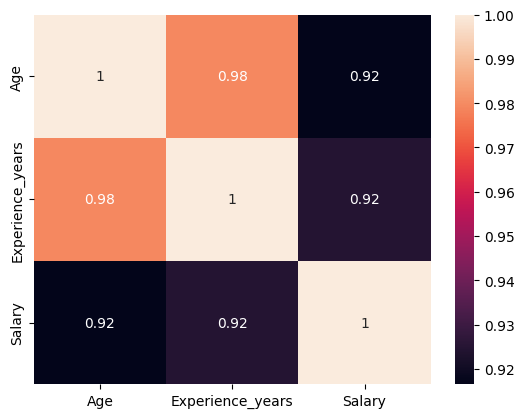

In [81]:
sns.heatmap(corr, annot=True)

## Data Visualization - Bar Chart, Box plot, Histogram

In [82]:
salary_data['Degree'].value_counts()

Degree
Bachelor's    191
Master's       91
PhD            42
Name: count, dtype: int64

<Axes: xlabel='Degree'>

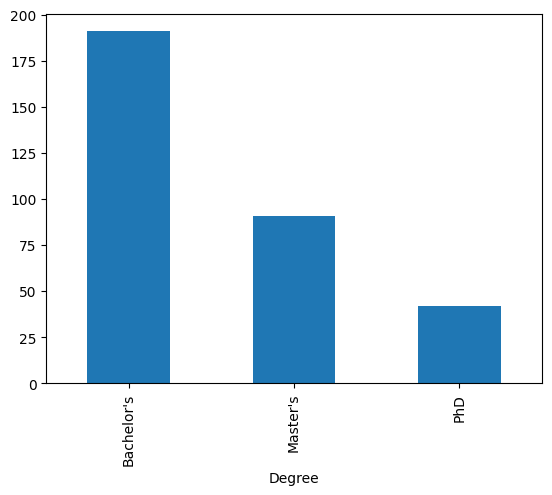

In [83]:
salary_data['Degree'].value_counts().plot(kind='bar')

In [84]:
salary_data['Job_Title'].value_counts()

Job_Title
Director of Operations           9
Director of Marketing            8
Senior Marketing Manager         8
Senior Project Manager           7
Senior Data Scientist            6
                                ..
Junior Research Scientist        1
Senior HR Specialist             1
Junior Operations Coordinator    1
Director of HR                   1
Junior Financial Advisor         1
Name: count, Length: 174, dtype: int64

<Axes: ylabel='Gender'>

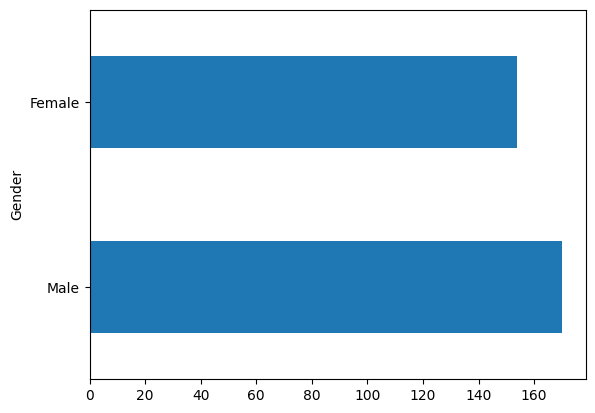

In [85]:
salary_data['Gender'].value_counts().plot(kind='barh')

<Axes: ylabel='Frequency'>

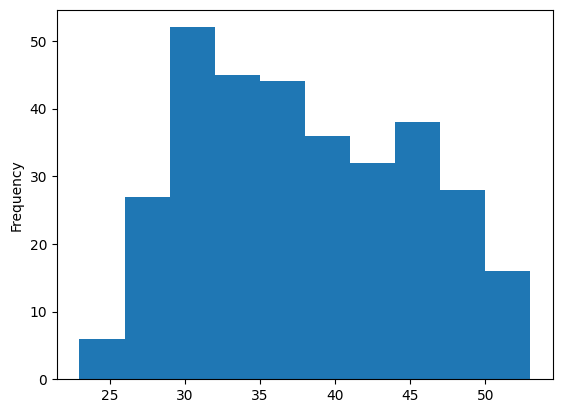

In [86]:
salary_data['Age'].plot(kind='hist')

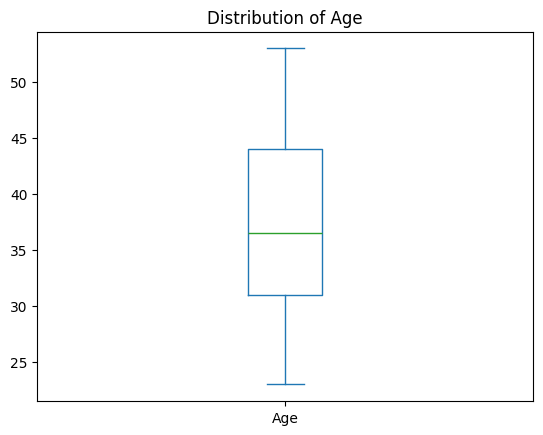

In [87]:
salary_data.Age.plot(kind='box')
plt.title('Distribution of Age');

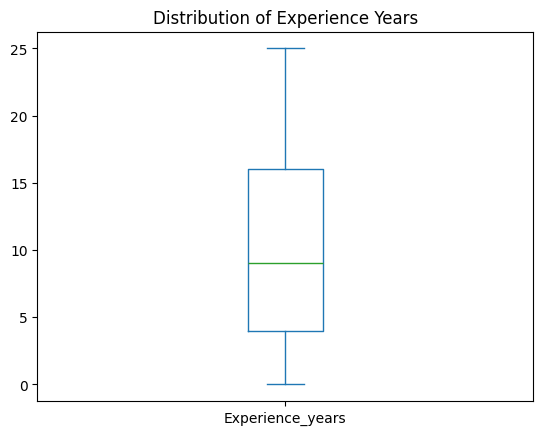

In [88]:
salary_data.Experience_years.plot(kind='box')
plt.title('Distribution of Experience Years');

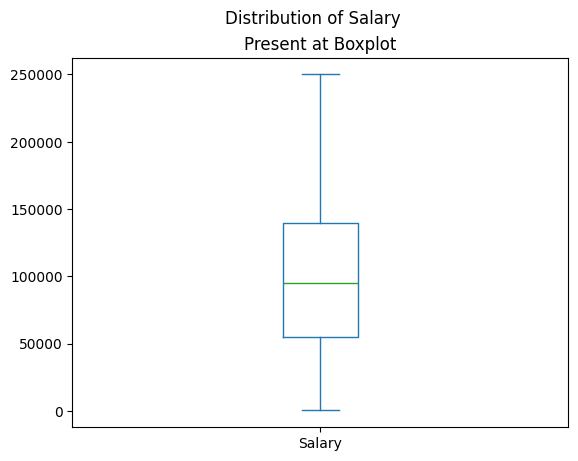

In [89]:
salary_data['Salary'].plot(kind='box')
plt.title('Present at Boxplot')
plt.suptitle('Distribution of Salary');

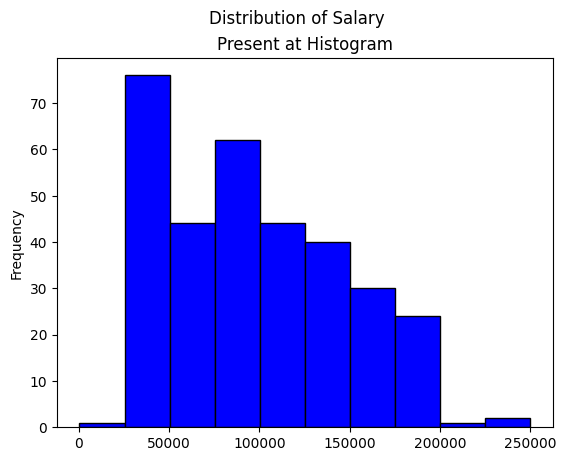

In [90]:
salary_data['Salary'].plot(kind='hist', bins=10,color='blue', edgecolor='k')
plt.title('Present at Histogram')
plt.suptitle('Distribution of Salary');

# Feature Engineering:

## Label Encoding:

In [91]:
from sklearn.preprocessing import LabelEncoder
LabelEncoder = LabelEncoder()

In [92]:
salary_data.head(2)

,Age,Gender,Degree,Job_Title,Experience_years,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0


In [93]:
salary_data['Gender_encode'] = LabelEncoder.fit_transform(salary_data['Gender'])

In [94]:
salary_data['Degree_Encode'] = LabelEncoder.fit_transform(salary_data['Degree'])

In [95]:
salary_data['Job_Title_Encode'] = LabelEncoder.fit_transform(salary_data['Job_Title'])

## Data After Label Encoding:

In [96]:
salary_data.head(5)

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_encode,Degree_Encode,Job_Title_Encode
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22


## Feature Scalling:

In [97]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [98]:
salary_data['Age_scaled'] = std_scaler.fit_transform(salary_data[['Age']])
salary_data['Experience_years_scaled'] = std_scaler.fit_transform(salary_data[['Experience_years']])

## Data After Scalling:

In [99]:
salary_data

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_encode,Degree_Encode,Job_Title_Encode,Age_scaled,Experience_years_scaled
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,-0.750231,-0.761821
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,-1.307742,-1.063017
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,1.061680,0.744158
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,-0.192720,-0.460625
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,2.037324,1.497148
...,...,...,...,...,...,...,...,...,...,...,...
348,28.0,Female,Bachelor's,Junior Operations Manager,1.0,35000.0,0,0,68,-1.307742,-1.364212
349,36.0,Male,Bachelor's,Senior Business Development Manager,8.0,110000.0,1,0,111,-0.192720,-0.310027
350,44.0,Female,PhD,Senior Data Scientist,16.0,160000.0,0,2,115,0.922302,0.894756
351,31.0,Male,Bachelor's,Junior Marketing Coordinator,3.0,55000.0,1,0,63,-0.889609,-1.063017


## Dependent and Independent features:

In [100]:
X = salary_data[['Age_scaled', 'Gender_encode', 'Degree_Encode', 'Job_Title_Encode', 'Experience_years_scaled']]
y = salary_data['Salary']

In [101]:
X.head()

,Age_scaled,Gender_encode,Degree_Encode,Job_Title_Encode,Experience_years_scaled
0,-0.750231,1,0,159,-0.761821
1,-1.307742,0,1,17,-1.063017
2,1.061680,1,2,130,0.744158
3,-0.192720,0,0,101,-0.460625
4,2.037324,1,1,22,1.497148


# Splitting the data into Traning and Testing:

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=2, random_state=42)

In [104]:
x_train.head()

,Age_scaled,Gender_encode,Degree_Encode,Job_Title_Encode,Experience_years_scaled
137,-1.028986,0,0,64,-0.912419
9,0.086036,1,2,150,-0.008831
181,-0.053342,1,1,110,-0.159429
126,-0.053342,0,1,121,-0.159429
221,-0.889609,0,0,75,-1.063017


In [105]:
x_train.shape, y_train.shape

((322, 5), (322,))

In [106]:
x_test.shape, y_test.shape

((2, 5), (2,))

# Model Development

In [107]:
from sklearn.linear_model import LinearRegression

In [108]:
Linear_Regression_Model = LinearRegression()

# Model training:

In [109]:
Linear_Regression_Model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[20834.36, 8593.26,14498.88, 20.72,18541.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Age_scaled','Gender_encode','Degree_Encode','Job_Title_Encode', 'Experience_years_scaled']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.593e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


# Model Predections:

In [110]:
y_pred_lr = Linear_Regression_Model.predict(x_test)
y_pred_lr

array([116640.60323923, 124652.36710871])

In [111]:
df = pd.DataFrame({'y_Actual': y_test, 'y_Predicted': y_pred_lr})
df['Error'] = df['y_Actual'] - df['y_Predicted']
df['abs_error'] = abs(df['Error'])
Mean_absolute_Error = df['abs_error'].mean()
Mean_absolute_Error

np.float64(20646.48517397097)

# Model Evaluation:

In [112]:
from sklearn.metrics import accuracy_score, r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Model Accuracy:

In [113]:
r2_score(y_test, y_pred_lr)

0.0

In [114]:
print(f"Accuracy of the Model = {round(r2_score(y_test, y_pred_lr), 4) * 100} %")

Accuracy of the Model = 0.0 %


# Mean Absolute Error:

In [115]:
mse = round(mean_absolute_error(y_test, y_pred_lr), 2)
mse 

20646.49

In [116]:
print(f'Mean Absolute Error = {round(mean_absolute_error(y_test, y_pred_lr), 2)}')

Mean Absolute Error = 20646.49


# Root Mean Squared Error: 

In [117]:
print(f'Root Mean Squared Error (RMSE) = ', mse**(0.5))

Root Mean Squared Error (RMSE) =  143.68886526102153


# Coefficeints:

In [118]:
Linear_Regression_Model.coef_

array([2.08343590e+04, 8.59326269e+03, 1.44988753e+04, 2.07200602e+01,
       1.85410260e+04])

# Intercepts:

In [119]:
Linear_Regression_Model.intercept_

np.float64(85929.91225003154)

In [120]:
salary_data.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_encode,Degree_Encode,Job_Title_Encode,Age_scaled,Experience_years_scaled
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,-0.750231,-0.761821
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,-1.307742,-1.063017
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,1.061680,0.744158
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,-0.192720,-0.460625
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,2.037324,1.497148


# Customise Predictions:

In [121]:
salary_data.head()

,Age,Gender,Degree,Job_Title,Experience_years,Salary,Gender_encode,Degree_Encode,Job_Title_Encode,Age_scaled,Experience_years_scaled
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0,1,0,159,-0.750231,-0.761821
1,28.0,Female,Master's,Data Analyst,3.0,65000.0,0,1,17,-1.307742,-1.063017
2,45.0,Male,PhD,Senior Manager,15.0,150000.0,1,2,130,1.061680,0.744158
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0,0,0,101,-0.192720,-0.460625
4,52.0,Male,Master's,Director,20.0,200000.0,1,1,22,2.037324,1.497148


- Age1 = std_scaler.transform([[49]])
- Age = 5.86448677
- Gender = 0
- Degree = 2
- Job_title = 22
- Experience_years1 = std_scaler.transform([[15]])
- Experience_years = 0.74415815

In [122]:
Age1 = std_scaler.transform([[49]])
Age = 5.86448677
Gender = 0
Degree = 2
Job_title = 22
Experience_years1 = std_scaler.transform([[15]])
Experience_years = 0.74415815

c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [123]:
std_scaler.transform([[15]])[0][0]

c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(0.7441581452572275)

In [124]:
Emp_salary = Linear_Regression_Model.predict([[Age, Gender, Degree, Job_title, Experience_years]])
Emp_salary

c:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([251363.78267148])

In [125]:
print(f'Salary of that Employee with above Attributes = ', Emp_salary[0])

Salary of that Employee with above Attributes =  251363.78267147634
